In [ ]:
!pip install seaborn -q

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

# Fresh raw copy for categorical group analysis
df_raw = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df_raw['Attrition_num'] = df_raw['Attrition'].map({'Yes': 1, 'No': 0})

# --- Class Balance ---
counts = df_raw['Attrition'].value_counts()
rate   = df_raw['Attrition_num'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

bars = axes[0].bar(counts.index, counts.values, color=['steelblue', 'salmon'], edgecolor='white', width=0.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 15, str(v), ha='center', fontweight='bold')
axes[0].set_title(f'Count  |  Attrition Rate: {rate:.1f}%')
axes[0].set_ylabel('Employees')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Attrition Split')

plt.suptitle('Class Balance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
dept_rate    = df_raw.groupby('Department')['Attrition_num'].mean().sort_values() * 100
jobrole_rate = df_raw.groupby('JobRole')['Attrition_num'].mean().sort_values() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(dept_rate.index, dept_rate.values, color='steelblue', edgecolor='white')
for i, v in enumerate(dept_rate.values):
    axes[0].text(v + 0.4, i, f'{v:.1f}%', va='center')
axes[0].set_xlabel('Attrition Rate (%)')
axes[0].set_title('Attrition Rate by Department')
axes[0].set_xlim(0, dept_rate.max() + 10)

colors = sns.color_palette('muted', len(jobrole_rate))
axes[1].barh(jobrole_rate.index, jobrole_rate.values, color=colors, edgecolor='white')
for i, v in enumerate(jobrole_rate.values):
    axes[1].text(v + 0.4, i, f'{v:.1f}%', va='center')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_title('Attrition Rate by Job Role')
axes[1].set_xlim(0, jobrole_rate.max() + 10)

plt.suptitle('Attrition by Department & Job Role', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Overtime vs Attrition
ot = df_raw.groupby('OverTime')['Attrition_num'].mean() * 100
axes[0, 0].bar(ot.index, ot.values, color=['steelblue', 'salmon'], edgecolor='white', width=0.4)
for i, v in enumerate(ot.values):
    axes[0, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0, 0].set_title('Overtime vs Attrition')
axes[0, 0].set_ylabel('Attrition Rate (%)')
axes[0, 0].set_ylim(0, ot.max() + 10)

# Distance from Home
for label, grp in df_raw.groupby('Attrition'):
    axes[0, 1].hist(grp['DistanceFromHome'], bins=15, alpha=0.6, label=label, edgecolor='white')
axes[0, 1].set_title('Distance from Home Distribution')
axes[0, 1].set_xlabel('Distance (miles)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(title='Attrition')

# Satisfaction scores attrition rate
sat_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction', 'JobInvolvement', 'WorkLifeBalance']
sat_rates = {col: df_raw.groupby(col)['Attrition_num'].mean() * 100 for col in sat_cols}

for ax, (col, rates) in zip([axes[0, 2], axes[1, 0], axes[1, 1], axes[1, 2]], sat_rates.items()):
    ax.bar(rates.index.astype(str), rates.values, color=sns.color_palette('muted', len(rates)), edgecolor='white')
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)
    ax.set_title(f'{col}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Attrition Rate (%)')
    ax.set_ylim(0, rates.max() + 8)

# Hide unused subplot (last one used for WorkLifeBalance above)
fig.delaxes(axes[1, 2]) if len(sat_cols) < 5 else None

plt.suptitle('Overtime, Distance & Satisfaction Scores vs Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

tenure_cols = ['YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion']
titles      = ['Years at Company', 'Years in Current Role', 'Years Since Last Promotion']

for ax, col, title in zip(axes, tenure_cols, titles):
    for label, grp in df_raw.groupby('Attrition'):
        ax.hist(grp[col], bins=15, alpha=0.6, label=label, edgecolor='white', density=True)
    ax.set_title(title)
    ax.set_xlabel('Years')
    ax.set_ylabel('Density')
    ax.legend(title='Attrition')

plt.suptitle('Tenure & Promotion Distributions by Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Correlation Heatmap ---
numeric_cols = ['Age', 'Attrition_num', 'DailyRate', 'DistanceFromHome',
                'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
                'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike',
                'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
                'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
                'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

corr_df = df_raw[numeric_cols].copy()
corr_df['OverTime'] = df_raw['OverTime'].map({'Yes': 1, 'No': 0})
corr = corr_df.corr().rename(columns={'Attrition_num': 'Attrition'},
                              index={'Attrition_num': 'Attrition'})

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

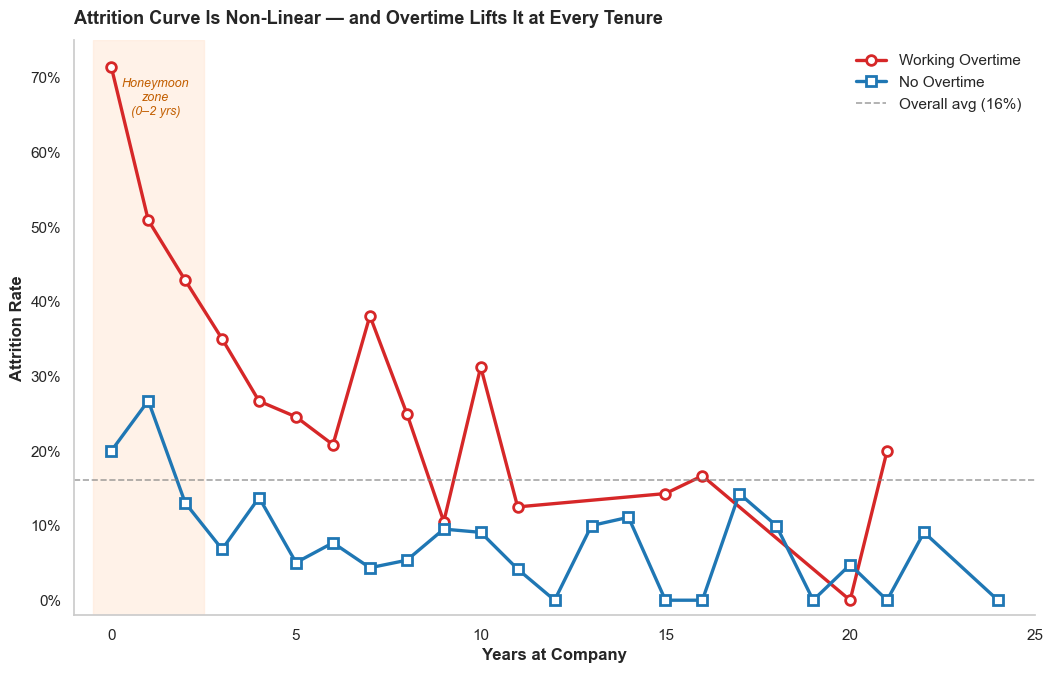

In [16]:
agg = (df_raw.groupby(['YearsAtCompany', 'OverTime'])
              .agg(rate=('Attrition_num', 'mean'),
                   n=('Attrition_num', 'size'))
              .reset_index())

agg = agg[agg['n'] >= 5]

ot_yes = agg[agg['OverTime'] == 'Yes'].sort_values('YearsAtCompany')
ot_no  = agg[agg['OverTime'] == 'No' ].sort_values('YearsAtCompany')

overall_rate = df_raw['Attrition_num'].mean()

fig, ax = plt.subplots(figsize=(11, 7.2))  # slightly taller figure

# Highlight honeymoon zone
ax.axvspan(-0.5, 2.5, color='#FFE8D6', alpha=0.55, zorder=0)

# Move annotation text slightly right and upward
ax.text(
    1.2, 0.70,
    'Honeymoon\nzone\n(0–2 yrs)',
    ha='center',
    va='top',
    fontsize=9,
    color='#C25E00',
    fontstyle='italic'
)

# Overtime line
ax.plot(
    ot_yes['YearsAtCompany'],
    ot_yes['rate'],
    marker='o',
    linewidth=2.4,
    color='#D62728',
    label='Working Overtime',
    markersize=7,
    markerfacecolor='white',
    markeredgewidth=2
)

# No overtime line
ax.plot(
    ot_no['YearsAtCompany'],
    ot_no['rate'],
    marker='s',
    linewidth=2.4,
    color='#1F77B4',
    label='No Overtime',
    markersize=6.5,
    markerfacecolor='white',
    markeredgewidth=2
)

# Overall average reference line
ax.axhline(
    overall_rate,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label=f'Overall avg ({overall_rate:.0%})'
)

# Remove background grid lines
ax.grid(False)

# Labels and title
ax.set_xlabel('Years at Company', fontweight='bold')
ax.set_ylabel('Attrition Rate', fontweight='bold')

ax.set_title(
    'Attrition Curve Is Non-Linear — and Overtime Lifts It at Every Tenure',
    fontsize=13,
    fontweight='bold',
    loc='left',
    pad=12
)

# Extend lower margin and overall spacing
ax.set_xlim(-1, 25)
ax.set_ylim(-0.02, 0.75)

# Format y-axis as percentages
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{int(y*100)}%')
)

# Clean style
ax.spines[['top', 'right']].set_visible(False)

# Legend
ax.legend(loc='upper right', frameon=False)

# Extra padding around figure
plt.tight_layout(pad=2)

plt.show()

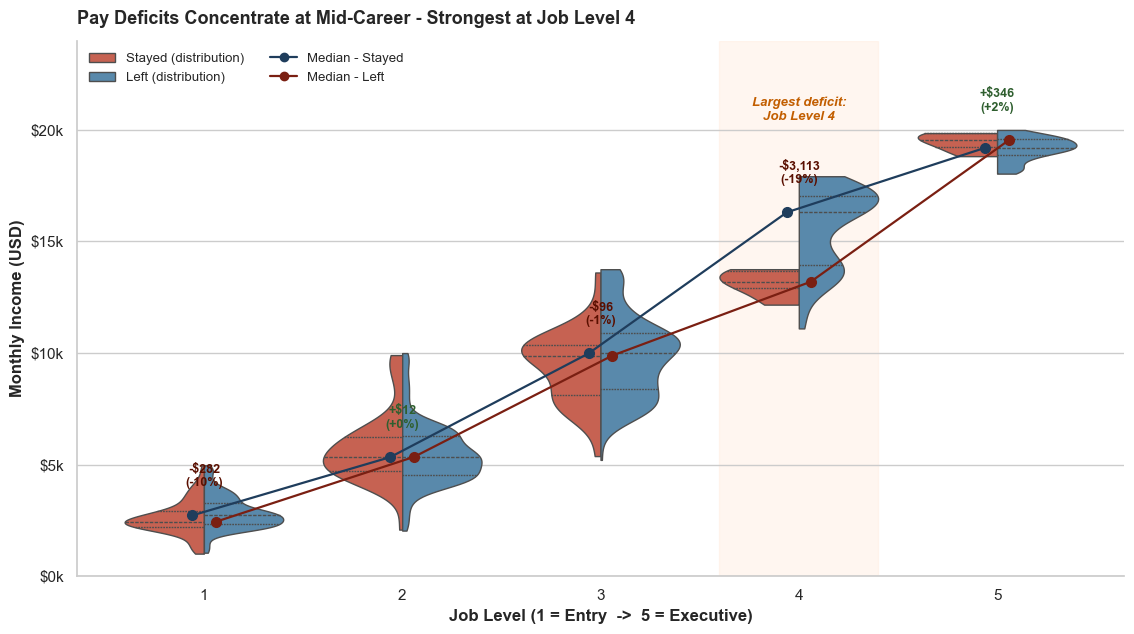

In [11]:
# Compensation deficit: MonthlyIncome distribution by JobLevel,
# split by Attrition. Shows where pay gaps between stayers and leavers
# concentrate - the empirical basis for the Retention-Bonus A/B test
# in notebook 04.

import numpy as np
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(11.5, 6.5))

sns.violinplot(
    data=df_raw, x='JobLevel', y='MonthlyIncome', hue='Attrition',
    split=True, inner='quartile', cut=0, density_norm='width',
    palette={'No': '#4C8BB8', 'Yes': '#D9543F'}, linewidth=1.0, ax=ax,
)

medians = (df_raw.groupby(['JobLevel', 'Attrition'])['MonthlyIncome']
                  .median().unstack('Attrition'))
x = np.arange(len(medians.index))

ax.plot(x - 0.06, medians['No'].values,  'o-', color='#1F3D5C',
        lw=1.6, ms=7, zorder=10)
ax.plot(x + 0.06, medians['Yes'].values, 'o-', color='#7A1F12',
        lw=1.6, ms=7, zorder=10)

# Sign-aware gap annotations (- if leavers earn less, + if more)
for i, lvl in enumerate(medians.index):
    stay  = medians.loc[lvl, 'No']
    leave = medians.loc[lvl, 'Yes']
    gap   = stay - leave
    pct   = gap / stay * 100
    sign  = '-' if gap > 0 else '+'
    color = '#5A0F00' if gap > 0 else '#2F5F2F'
    y_top = max(stay, leave)
    ax.annotate(f'{sign}${abs(gap):,.0f}\n({sign}{abs(pct):.0f}%)',
                xy=(i, y_top), xytext=(i, y_top + 1300),
                ha='center', fontsize=9, color=color, fontweight='bold')

# Highlight Job Level 4 - the dominant signal
ax.axvspan(2.6, 3.4, color='#FFE8D6', alpha=0.35, zorder=0)
ax.text(3, 21500, 'Largest deficit:\nJob Level 4',
        ha='center', va='top', fontsize=9.5, color='#C25E00',
        fontstyle='italic', fontweight='bold')

ax.set_xlabel('Job Level (1 = Entry  ->  5 = Executive)', fontweight='bold')
ax.set_ylabel('Monthly Income (USD)', fontweight='bold')
ax.set_title('Pay Deficits Concentrate at Mid-Career - Strongest at Job Level 4',
             fontsize=13, fontweight='bold', loc='left', pad=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}k'))
ax.set_ylim(0, 24000)

handles, _ = ax.get_legend_handles_labels()
median_stay  = mlines.Line2D([], [], color='#1F3D5C', marker='o', lw=1.6)
median_leave = mlines.Line2D([], [], color='#7A1F12', marker='o', lw=1.6)
ax.legend(handles[:2] + [median_stay, median_leave],
          ['Stayed (distribution)', 'Left (distribution)',
           'Median - Stayed', 'Median - Left'],
          loc='upper left', frameon=False, ncol=2, fontsize=9.5)

ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()